# Dataset Selection

In [1]:
#Dataset provided from huggging face: cite https://medium.com/data-science/counsel-chat-bootstrapping-high-quality-therapy-data-971b419f33da

In [2]:
!{sys.executable} -m pip install transformers

zsh:1: parse error near `-m'


In [3]:
pip install datasets

Note: you may need to restart the kernel to use updated packages.


In [4]:
#import statements
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import transformers#importing huggingface transformers library
from datasets import Dataset

In [5]:
# df = pd.read_csv('Dataset.csv')
# df

In [6]:
# import pandas as pd
# df = pd.read_csv('counselchat-data.csv')
# df


In [7]:
# import pandas as pd
# df = pd.read_csv('counsel_chat2.csv')
# df


In [8]:
#download from here: https://huggingface.co/datasets/nbertagnolli/counsel-chat/tree/main
df = pd.read_csv('20220401_counsel_chat.csv')
df

,questionID,questionTitle,questionText,questionLink,topic,therapistInfo,therapistURL,answerText,upvotes,views
0,0,Do I have too many issues for counseling?,I have so many issues to address. I have a his...,https://counselchat.com/questions/do-i-have-to...,depression,Jennifer MolinariHypnotherapist & Licensed Cou...,https://counselchat.com/therapists/jennifer-mo...,It is very common for people to have multiple ...,3,1971
1,0,Do I have too many issues for counseling?,I have so many issues to address. I have a his...,https://counselchat.com/questions/do-i-have-to...,depression,"Jason Lynch, MS, LMHC, LCAC, ADSIndividual & C...",https://counselchat.com/therapists/jason-lynch...,"I've never heard of someone having ""too many i...",2,386
2,0,Do I have too many issues for counseling?,I have so many issues to address. I have a his...,https://counselchat.com/questions/do-i-have-to...,depression,Shakeeta TorresFaith Based Mental Health Couns...,https://counselchat.com/therapists/shakeeta-to...,Absolutely not. I strongly recommending worki...,2,3071
3,0,Do I have too many issues for counseling?,I have so many issues to address. I have a his...,https://counselchat.com/questions/do-i-have-to...,depression,"Noorayne ChevalierMA, RP, CCC, CCAC, LLP (Mich...",https://counselchat.com/therapists/noorayne-ch...,Let me start by saying there are never too man...,2,2643
4,0,Do I have too many issues for counseling?,I have so many issues to address. I have a his...,https://counselchat.com/questions/do-i-have-to...,depression,"Toni Teixeira, LCSWYour road to healing begins...",https://counselchat.com/therapists/toni-teixei...,I just want to acknowledge you for the courage...,1,256
...,...,...,...,...,...,...,...,...,...,...
2770,939,Are some clients more difficult than others?,What are some difficulties that a counselor ca...,https://counselchat.com/questions/are-some-cli...,counseling-fundamentals,Audrey ONealBi-lingual Psychotherapist and Hea...,https://counselchat.com/therapists/audrey-oneal-3,Although many clients have the capacity to be ...,0,47
2771,939,Are some clients more difficult than others?,What are some difficulties that a counselor ca...,https://counselchat.com/questions/are-some-cli...,counseling-fundamentals,"Kaileen McMickle, MS, LPCLicensed Professional...",https://counselchat.com/therapists/kaileen-mcm...,"I usually don't label a client as ""difficult"" ...",0,22
2772,939,Are some clients more difficult than others?,What are some difficulties that a counselor ca...,https://counselchat.com/questions/are-some-cli...,counseling-fundamentals,"Dr. Timothy Paul'man'; Online - ""Natural Healt...",https://counselchat.com/therapists/dr-timothy-...,"Dang right! :)Heh heh, and correct me if I'm ...",0,23
2773,939,Are some clients more difficult than others?,What are some difficulties that a counselor ca...,https://counselchat.com/questions/are-some-cli...,counseling-fundamentals,"David KleinHumanistic, LGBT-Affirmative Psycho...",https://counselchat.com/therapists/david-klein,"Yes, just like some relationships outside of o...",0,41


# EDA

Eda Steps
- Analyze prevalence of Topics in the dataset
- Analyze trends in highly upvoted data
- Examine response length and complexity


In [9]:
print(f"Unqiue therapy questions: {len(df['questionTitle'].unique())}")

Unqiue therapy questions: 933


In [10]:
print(f"Unqiue therapy responses: {len(df['answerText'].unique())}")

Unqiue therapy responses: 2739


In [11]:
print(f"Unique Number of Therapists contributing to responses: {len(df['therapistInfo'].unique())}")

Unique Number of Therapists contributing to responses: 437


In [12]:
print(f"Number of Therapy Topics Discussed: {len(df['topic'].unique())}")

Number of Therapy Topics Discussed: 31


In [13]:
#avg number of characters per q
question_length = df['questionTitle'].apply(len)
average_length = question_length.mean()
print(f"Average Question Character Length: {average_length}")


Average Question Character Length: 48.72360360360361


In [14]:
#avg number of characters per q
answer_text_len = df['answerText'].dropna().apply(len)
average_length = answer_text_len.mean()
print(f"Average Answer Character Length: {average_length}")


Average Answer Character Length: 959.7366315023645


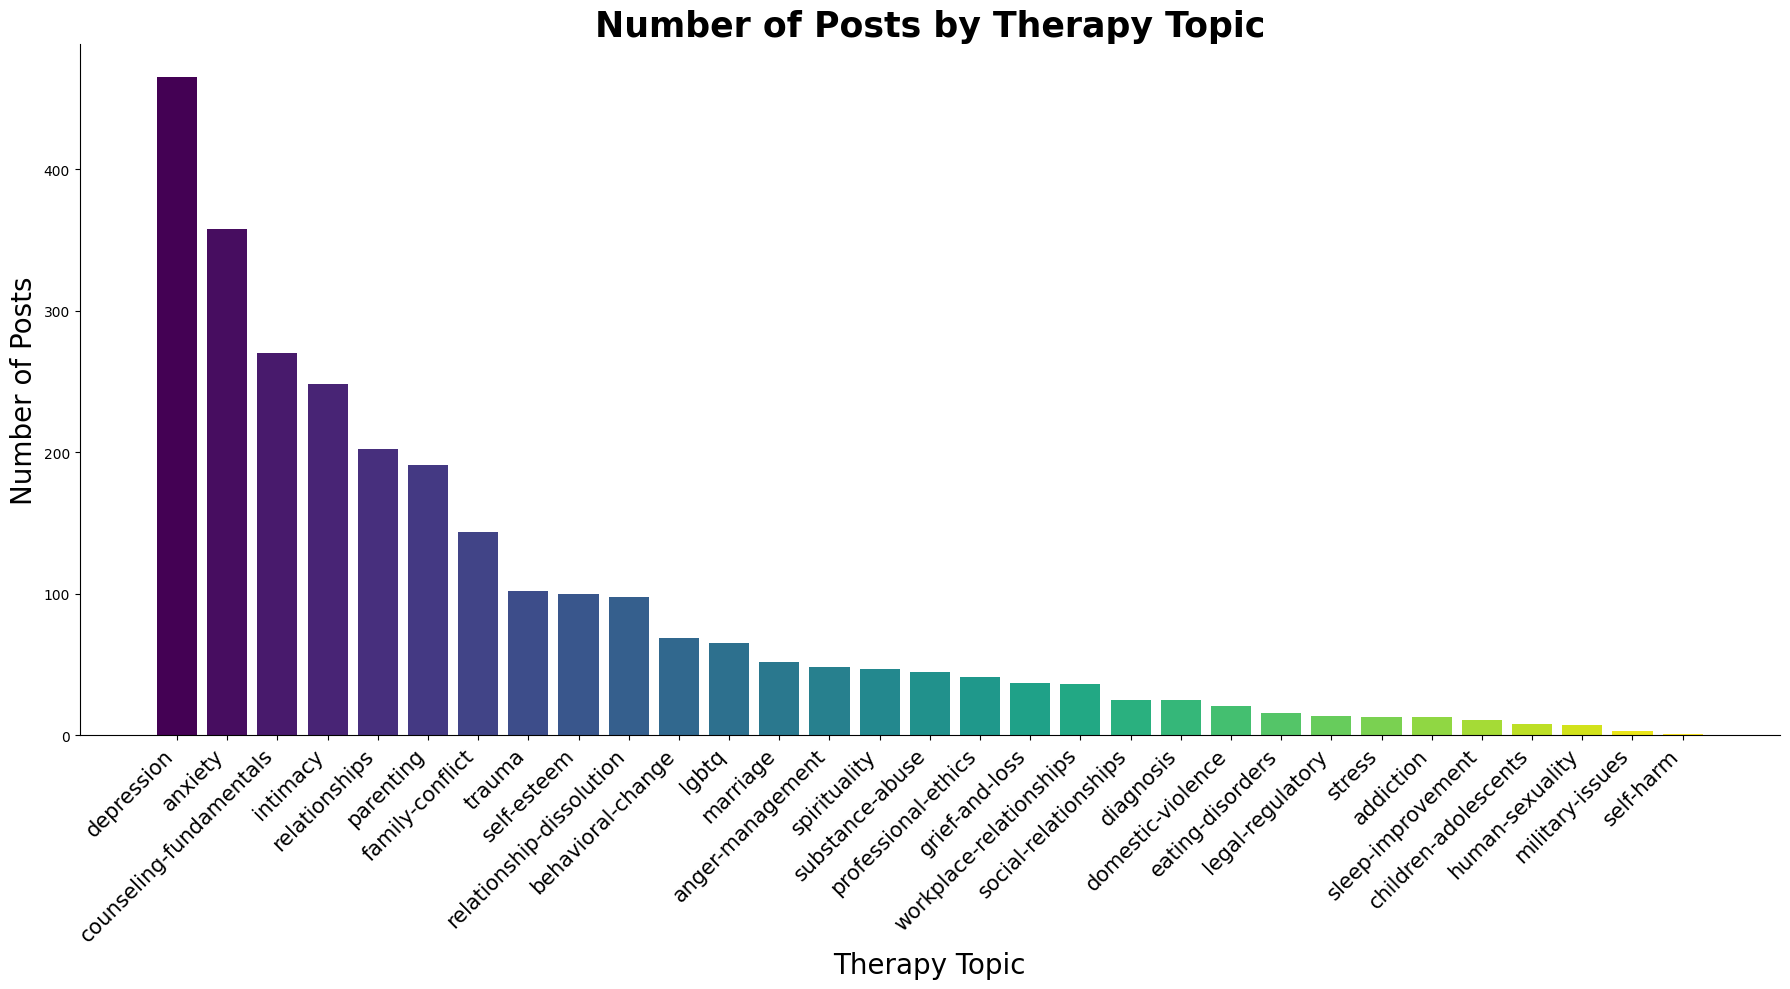

In [15]:
plt.figure(figsize=(18, 10))
counts = df['topic'].value_counts()


colors = plt.cm.viridis(np.linspace(0, 1, len(counts)))

plt.bar(counts.index, counts.values, color=colors)
plt.xlabel('Therapy Topic', fontsize = 20)
plt.ylabel('Number of Posts', fontsize = 20)
plt.title('Number of Posts by Therapy Topic',fontweight = "bold", fontsize = 25)

plt.xticks(rotation=45, ha='right', fontsize = 15)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/num_posts_therapy_topic.png')
plt.show()

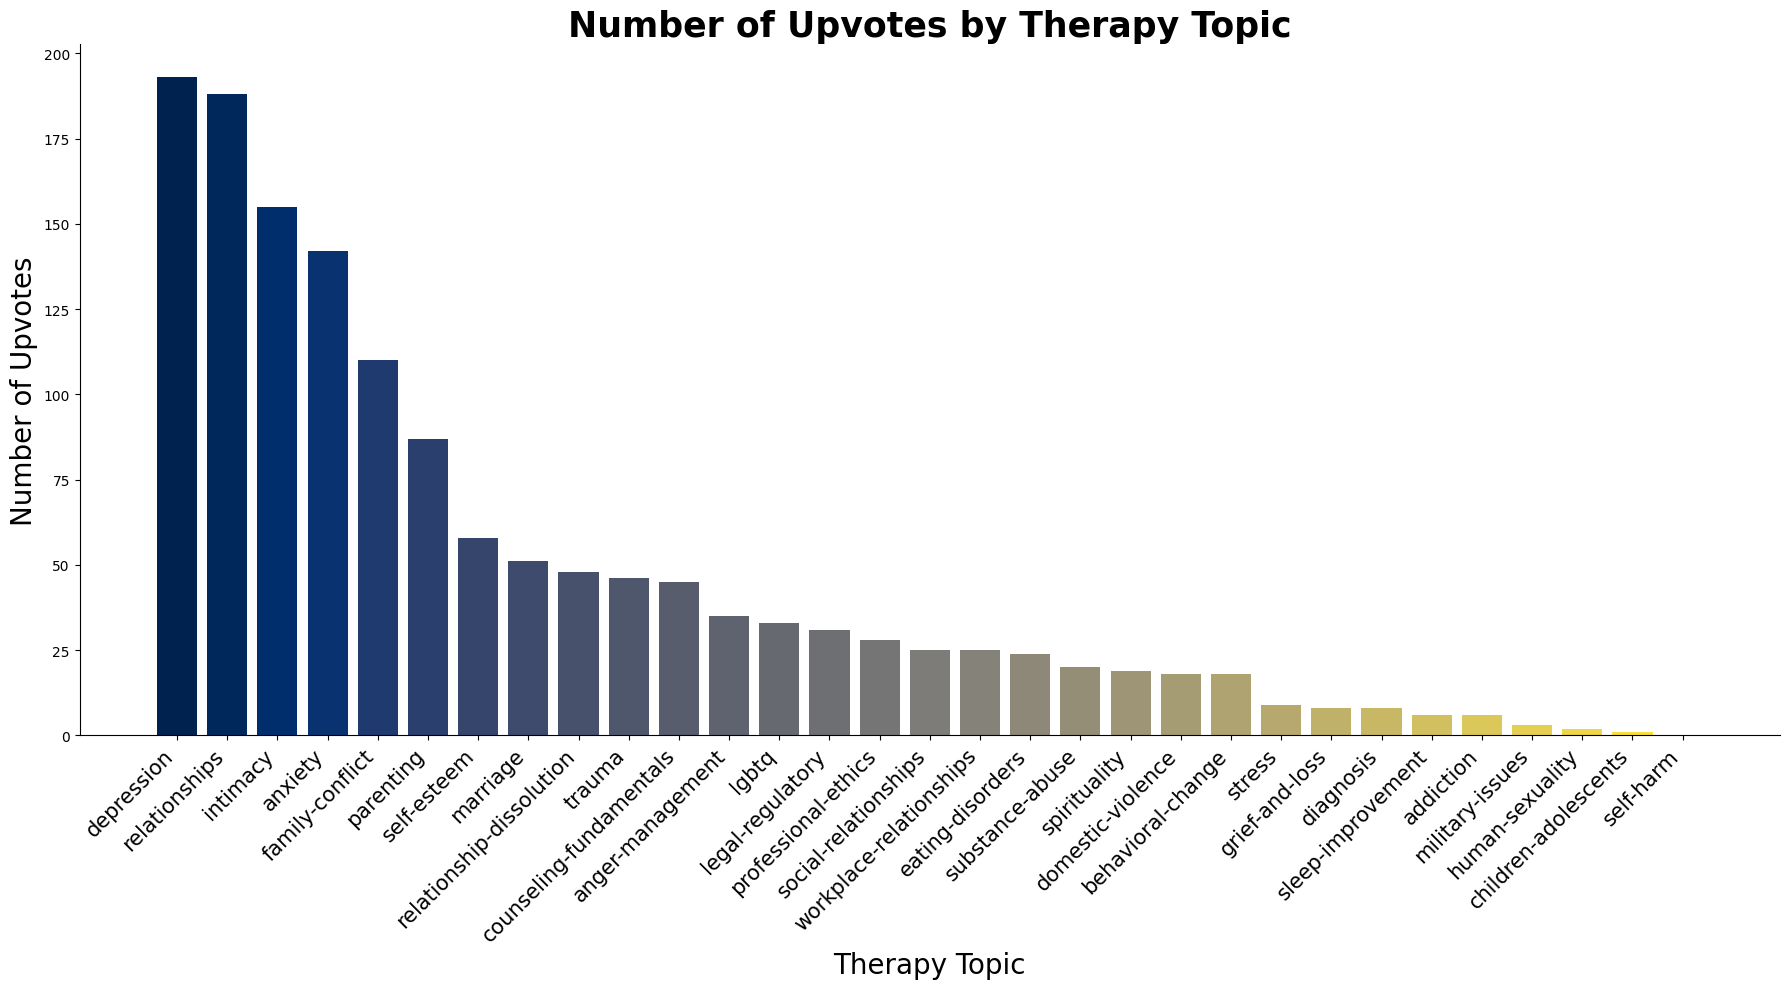

In [16]:

plt.figure(figsize=(18, 10))
counts = df.groupby('topic')['upvotes'].sum().sort_values(ascending=False)
colors = plt.cm.cividis(np.linspace(0, 1, len(counts)))

plt.bar(counts.index, counts.values, color=colors)

plt.xlabel('Therapy Topic', fontsize=20)
plt.ylabel('Number of Upvotes', fontsize=20)
plt.title('Number of Upvotes by Therapy Topic', fontweight="bold", fontsize=25)

plt.xticks(rotation=45, ha='right', fontsize=15)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/num_upvotes_therapy_topic.png')
plt.show()

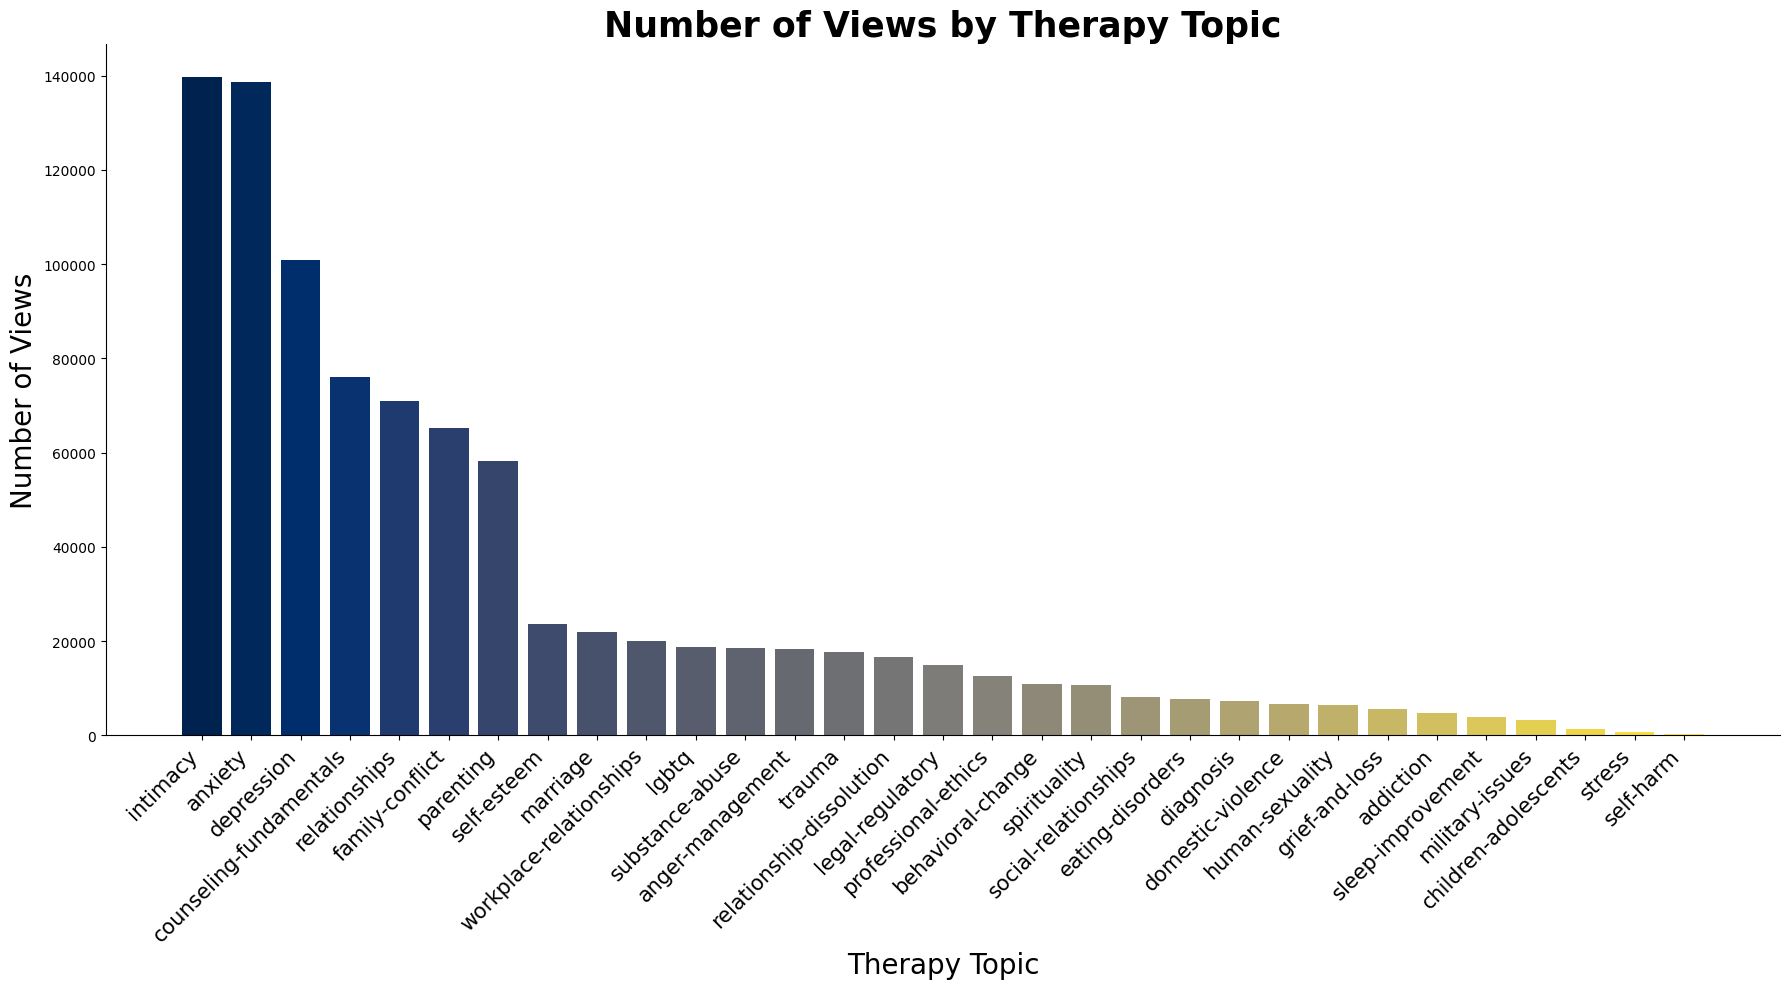

In [17]:
plt.figure(figsize=(18, 10))
counts = df.groupby('topic')['views'].sum().sort_values(ascending=False)
colors = plt.cm.cividis(np.linspace(0, 1, len(counts)))

plt.bar(counts.index, counts.values, color=colors)

plt.xlabel('Therapy Topic', fontsize=20)
plt.ylabel('Number of Views', fontsize=20)
plt.title('Number of Views by Therapy Topic', fontweight="bold", fontsize=25)

plt.xticks(rotation=45, ha='right', fontsize=15)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/num_views_therapy_topic.png')

plt.show()

# Building V1 of Chatbot

In [18]:
#https://medium.com/huggingface/how-to-build-a-state-of-the-art-conversational-ai-with-transfer-learning-2d818ac26313
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch


model_name = "Qwen/Qwen2.5-0.5B"#selected pretrained model from huggingface

tokenizer = AutoTokenizer.from_pretrained(model_name)#converting text --> tokens
model = AutoModelForCausalLM.from_pretrained(model_name, dtype=torch.float32)#loading in Qwen model

model.eval()

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 896)
    (layers): ModuleList(
      (0-23): 24 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=896, out_features=896, bias=True)
          (k_proj): Linear(in_features=896, out_features=128, bias=True)
          (v_proj): Linear(in_features=896, out_features=128, bias=True)
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
          (up_proj): Linear(in_features=896, out_features=4864, bias=False)
          (down_proj): Linear(in_features=4864, out_features=896, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((896,), eps=1e-06)
    (rotary_emb): Qwen2RotaryEmbe

In [19]:
#getting QWEN 2 loaded into jupyter notebook for conversation
def chat_with_model(prompt, max_new_tokens=100, temperature=0.7, top_p=0.9):
    inputs = tokenizer(prompt, return_tensors="pt")
    

    with torch.no_grad():  
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            top_p=top_p,
            do_sample=True,        
            pad_token_id=tokenizer.eos_token_id
        )
    
    text_output = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return text_output


In [20]:
user_input = "Hello! Can you explain what fine-tuning a model is?"
response = chat_with_model(user_input)
print(response)

Hello! Can you explain what fine-tuning a model is? Sure, I'd be happy to help! When we train a model, we're essentially trying to make the model perform better by adjusting its parameters. Fine-tuning a model is one way to do this. It involves training the model on a smaller, more specific dataset than the original training dataset. This smaller dataset is called the fine-tuning dataset, and the model is trained on it to improve its performance. The process of fine-tuning is often repeated until the model reaches a desired level of


Next steps: 
- fine-tune the pretrained QWEN model using the trainer from HuggingFace
  - https://huggingface.co/docs/transformers/training#fine-tune-on-a-custom-dataset
- https://huggingface.co/docs/transformers/training
